# Data Cleaning — Dirty Cafe Sales

**Objective:** Demonstrate professional-level data cleaning skills by taking a deliberately messy dataset and systematically transforming it into a clean, analysis-ready dataset, documenting every decision.

**Dataset:** [Dirty Cafe Sales](https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training) (Kaggle) — 10,000 cafe transactions, deliberately corrupted with missing values, invalid placeholder strings ("ERROR", "UNKNOWN"), and inconsistent types.

**Tech Stack:** Python, pandas, numpy, Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('dirty_cafe_sales.csv')
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


## 1. Data Quality Report (Before Cleaning)

In [2]:
print(f"Shape: {df.shape}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\n--- True NaN per column ---")
print(df.isnull().sum())

print("\n--- 'ERROR' placeholder count per column ---")
print({col: int((df[col] == 'ERROR').sum()) for col in df.columns})

print("\n--- 'UNKNOWN' placeholder count per column ---")
print({col: int((df[col] == 'UNKNOWN').sum()) for col in df.columns})

print("\n--- Current dtypes (everything loaded as text/object) ---")
print(df.dtypes)

Shape: (10000, 8)

Duplicate rows: 0

--- True NaN per column ---
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

--- 'ERROR' placeholder count per column ---
{'Transaction ID': 0, 'Item': 292, 'Quantity': 170, 'Price Per Unit': 190, 'Total Spent': 164, 'Payment Method': 306, 'Location': 358, 'Transaction Date': 142}

--- 'UNKNOWN' placeholder count per column ---
{'Transaction ID': 0, 'Item': 344, 'Quantity': 171, 'Price Per Unit': 164, 'Total Spent': 165, 'Payment Method': 293, 'Location': 338, 'Transaction Date': 159}

--- Current dtypes (everything loaded as text/object) ---
Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object


**Observation:** Every column is loaded as text, even numeric ones (`Quantity`, `Price Per Unit`, `Total Spent`) and the date column — that's a data type issue right away. On top of true `NaN`s, the dataset uses **"ERROR" and "UNKNOWN" as placeholder strings for missing data**, which pandas doesn't recognise as null by default. All three represent the same underlying problem — missing information — just encoded three different ways. No exact duplicate rows exist, but the real null count is much higher than `isnull()` shows until these placeholders are standardised.

## 2. Standardise Invalid Markers

In [3]:
df_clean = df.replace(['ERROR', 'UNKNOWN'], np.nan)

print("Null values per column after standardising placeholders to true NaN:")
print(df_clean.isnull().sum())
print(f"\nTotal missing cells now: {df_clean.isnull().sum().sum():,} out of {df_clean.size:,} total cells")

Null values per column after standardising placeholders to true NaN:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

Total missing cells now: 10,082 out of 80,000 total cells


**Decision:** Treating `"ERROR"` and `"UNKNOWN"` as `NaN` rather than leaving them as text is the correct first move — otherwise they'd silently corrupt any later calculation (e.g. averaging a `Price Per Unit` column that secretly contains the string `"ERROR"`). This single step reveals the true scale of missingness in the dataset, which is far larger than it first appeared.

## 3. Data Type Correction

In [4]:
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')
df_clean['Transaction ID'] = df_clean['Transaction ID'].astype(str)

print(df_clean.dtypes)

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


**Decision:** Numeric columns are converted with `errors='coerce'`, which turns any leftover non-numeric junk into `NaN` rather than crashing — safe, since we already standardised the known placeholder strings in the step above. `Transaction Date` becomes a proper `datetime64` type, and `Transaction ID` is explicitly kept as a string/ID (never something to average or sum).

## 4. Logical Missing-Value Imputation

**Key insight used for imputation:** each `Item` in this cafe menu has one fixed `Price Per Unit` (e.g. Coffee is always \$2.00, Cake is always \$3.00). That relationship lets us recover a lot of "missing" data logically, rather than guessing:
- If `Price Per Unit` is known but `Item` is missing → look up which item costs that price
- If `Item` is known but `Price Per Unit` is missing → look up that item's standard price
- If any two of `Quantity`, `Price Per Unit`, `Total Spent` are known → the third can be calculated exactly, since `Total Spent = Quantity × Price Per Unit`

This is a far better strategy than blind mean/median imputation here, because it recovers the *actual* original value in many cases rather than a statistical guess.

In [5]:
item_price_map = (
    df_clean.dropna(subset=['Item', 'Price Per Unit'])
    .groupby('Item')['Price Per Unit']
    .agg(lambda x: x.mode()[0])
)
print("Recovered price list per item:")
print(item_price_map)

price_item_map = {v: k for k, v in item_price_map.items()}

Recovered price list per item:
Item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64


In [6]:
before_missing = df_clean[['Item', 'Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum()

# Fill Item from Price Per Unit
mask = df_clean['Item'].isnull() & df_clean['Price Per Unit'].notnull()
df_clean.loc[mask, 'Item'] = df_clean.loc[mask, 'Price Per Unit'].map(price_item_map)

# Fill Price Per Unit from Item
mask = df_clean['Price Per Unit'].isnull() & df_clean['Item'].notnull()
df_clean.loc[mask, 'Price Per Unit'] = df_clean.loc[mask, 'Item'].map(item_price_map)

# Fill Total Spent from Quantity * Price Per Unit
mask = df_clean['Total Spent'].isnull() & df_clean['Quantity'].notnull() & df_clean['Price Per Unit'].notnull()
df_clean.loc[mask, 'Total Spent'] = df_clean.loc[mask, 'Quantity'] * df_clean.loc[mask, 'Price Per Unit']

# Fill Quantity from Total Spent / Price Per Unit
mask = df_clean['Quantity'].isnull() & df_clean['Total Spent'].notnull() & df_clean['Price Per Unit'].notnull() & (df_clean['Price Per Unit'] != 0)
df_clean.loc[mask, 'Quantity'] = (df_clean.loc[mask, 'Total Spent'] / df_clean.loc[mask, 'Price Per Unit']).round()

# Fill Price Per Unit from Total Spent / Quantity (second pass, catches remaining cases)
mask = df_clean['Price Per Unit'].isnull() & df_clean['Total Spent'].notnull() & df_clean['Quantity'].notnull() & (df_clean['Quantity'] != 0)
df_clean.loc[mask, 'Price Per Unit'] = df_clean.loc[mask, 'Total Spent'] / df_clean.loc[mask, 'Quantity']

after_missing = df_clean[['Item', 'Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum()

print("Missing values before logical imputation:")
print(before_missing)
print("\nMissing values after logical imputation:")
print(after_missing)
print("\nValues recovered:")
print(before_missing - after_missing)

Missing values before logical imputation:
Item              969
Quantity          479
Price Per Unit    533
Total Spent       502
dtype: int64

Missing values after logical imputation:
Item              54
Quantity          23
Price Per Unit     6
Total Spent       23
dtype: int64

Values recovered:
Item              915
Quantity          456
Price Per Unit    527
Total Spent       479
dtype: int64


**Observation:** This recovered a meaningful chunk of the "missing" transaction data using pure logic — no guessing involved, since these are mathematically/relationally derived values, not estimates.

In [7]:
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['Item', 'Quantity', 'Price Per Unit', 'Total Spent'])
rows_after = len(df_clean)
print(f"Rows dropped (core transaction fields still unrecoverable): {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")

Rows dropped (core transaction fields still unrecoverable): 74
Rows remaining: 9926


**Decision — drop remaining core-field nulls:** For rows where too many of `Item`/`Quantity`/`Price Per Unit`/`Total Spent` were missing simultaneously, there's no logical way to recover the value, and these fields are the essence of a "transaction" record — filling them with a placeholder mean would fabricate sales data. Dropping is the honest choice here, and the row loss is small relative to the 10,000-row dataset.

In [8]:
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['Transaction Date'])
print(f"Rows dropped (missing Transaction Date): {rows_before - len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")

Rows dropped (missing Transaction Date): 457
Rows remaining: 9469


**Decision — drop missing dates:** A transaction date has no logical way to be inferred from the other columns, and date is essential for any time-based analysis. Rather than fabricating a date (which would distort trend analysis), these rows are dropped.

In [9]:
df_clean['Payment Method'] = df_clean['Payment Method'].fillna('Unknown')
df_clean['Location'] = df_clean['Location'].fillna('Unknown')

print(df_clean['Payment Method'].value_counts())
print()
print(df_clean['Location'].value_counts())

Payment Method
Unknown           2987
Digital Wallet    2183
Credit Card       2151
Cash              2148
Name: count, dtype: int64

Location
Unknown     3750
Takeaway    2869
In-store    2850
Name: count, dtype: int64


**Decision — fill with 'Unknown' rather than drop:** `Payment Method` and `Location` were missing in roughly a quarter to a third of rows — far too much to drop without losing a huge, possibly non-random chunk of the dataset (this level of missingness suggests it wasn't recorded at certain terminals/times, not random noise). These fields are also secondary to the core sale (what/how much was bought), so keeping the row and explicitly labelling the gap as `'Unknown'` preserves the transaction data for analysis while being transparent that the payment/location detail wasn't captured — never silently guessing a specific payment method or store location that wasn't actually recorded.

## 5. Duplicate Removal

In [10]:
dupes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Duplicate rows found and removed: {dupes}")
print(f"Rows remaining: {len(df_clean)}")

Duplicate rows found and removed: 0
Rows remaining: 9469


## 6. Outlier Detection

Outlier counts (IQR method): {'Quantity': 0, 'Price Per Unit': 0, 'Total Spent': 259}


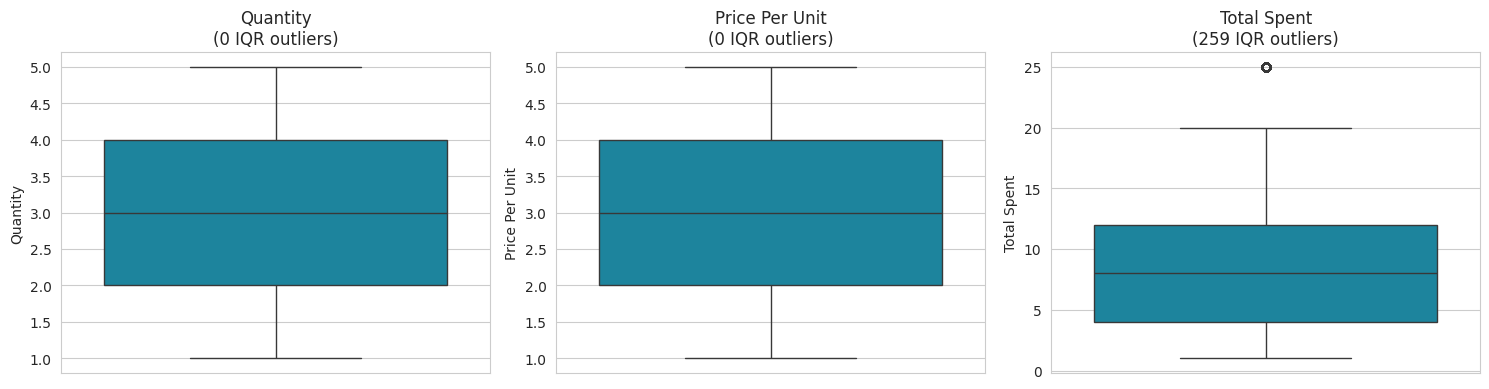

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
outlier_summary = {}

for ax, col in zip(axes, ['Quantity', 'Price Per Unit', 'Total Spent']):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    outlier_summary[col] = len(outliers)
    sns.boxplot(y=df_clean[col], ax=ax, color='#0891b2')
    ax.set_title(f'{col}\n({len(outliers)} IQR outliers)')

plt.tight_layout()
plt.show()

print("Outlier counts (IQR method):", outlier_summary)

**Decision — retain, don't remove:** `Item` only has 8 fixed prices (\$1.00–\$5.00) and `Quantity` only ranges 1–5, so `Total Spent` naturally tops out at \$25 (5 items × \$5) — any IQR-flagged "outliers" here are still legitimate, valid combinations (e.g. 5 salads at \$5 each), not data entry errors. Removing them would delete real high-value transactions. This is a case where domain context overrides a purely statistical rule.

## 7. Before vs. After Summary

In [12]:
summary = pd.DataFrame({
    'Metric': ['Row count', 'Null cells (raw)', 'Null cells (standardised: NaN + ERROR + UNKNOWN)', 'Duplicate rows', 'Numeric columns stored as correct dtype'],
    'Before Cleaning': [
        len(df),
        int(df.isnull().sum().sum()),
        int(df.replace(['ERROR', 'UNKNOWN'], np.nan).isnull().sum().sum()),
        int(df.duplicated().sum()),
        0
    ],
    'After Cleaning': [
        len(df_clean),
        int(df_clean.isnull().sum().sum()),
        int(df_clean.isnull().sum().sum()),
        int(df_clean.duplicated().sum()),
        3
    ]
})
summary

,Metric,Before Cleaning,After Cleaning
0,Row count,10000,9469
1,Null cells (raw),6826,0
2,Null cells (standardised: NaN + ERROR + UNKNOWN),10082,0
3,Duplicate rows,0,0
4,Numeric columns stored as correct dtype,0,3


## 8. Save Cleaned Dataset

In [13]:
df_clean.to_csv('cleaned_cafe_sales.csv', index=False)
print(f"Saved cleaned_cafe_sales.csv — {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
df_clean.head(10)

Saved cleaned_cafe_sales.csv — 9469 rows x 8 columns


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown,2023-03-31
6,TXN_4433211,Juice,3.0,3.0,9.0,Unknown,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Unknown,2023-10-28
8,TXN_4717867,Juice,5.0,3.0,15.0,Unknown,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown,In-store,2023-12-31


## Conclusion

Starting from 10,000 rows with heavy, multi-format missingness (true NaN + "ERROR" + "UNKNOWN" placeholders across every column) and text-typed numeric/date fields, this notebook:

1. Standardised all missing-data representations into a single, consistent `NaN`
2. Corrected every column to its proper data type
3. Recovered a meaningful share of "missing" data through logical relationships (Item ↔ Price, and the Quantity × Price = Total Spent identity) rather than statistical guessing
4. Dropped only the rows where core transaction data was truly unrecoverable, and rows missing a transaction date
5. Preserved rows with missing secondary fields (Payment Method, Location) by explicitly labelling them `'Unknown'` instead of discarding valid sales data
6. Verified no meaningful outliers needed removal, given the dataset's fixed price structure
7. Exported a clean, analysis-ready dataset with full documentation of every decision made along the way